## Simple Linear Regression 
#### Dataset : California Housing dataset


### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
w.filterwarnings("ignore")
import math
from statsmodels.stats.outliers_influence import variance_inflation_factor

### Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/california-housing-with-name-of-counties/California_Housing_CitiesAdded.csv")
df.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco,ocean_proximity,City
0,500001.0,1.2434,52,249,78,396,85,37.80,-122.27,2524.614616,552234.0515,731023.5749,61415.35211,14466.70538,NEAR BAY,Alameda
1,500001.0,1.1696,52,609,236,1349,250,37.87,-122.25,7897.024567,556856.9280,735788.3723,67242.51828,19172.81885,NEAR BAY,Alameda
2,500001.0,7.8521,52,1668,225,517,214,37.86,-122.24,9154.528309,555442.5086,734372.6023,65849.13943,19335.74118,NEAR BAY,Alameda
3,500001.0,9.3959,52,3726,474,1366,496,37.85,-122.24,8259.085109,554610.7171,733525.6829,64867.28983,18811.48745,NEAR BAY,Alameda
4,500001.0,7.8772,52,2990,379,947,361,37.83,-122.23,7284.913015,552365.4712,731263.5682,62493.11252,18750.94628,NEAR BAY,Alameda


### Data Spread Check 

In [3]:
df.duplicated().sum()

np.int64(0)

In [4]:
df.shape

(20640, 16)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Median_House_Value        20640 non-null  float64
 1   Median_Income             20640 non-null  float64
 2   Median_Age                20640 non-null  int64  
 3   Tot_Rooms                 20640 non-null  int64  
 4   Tot_Bedrooms              20640 non-null  int64  
 5   Population                20640 non-null  int64  
 6   Households                20640 non-null  int64  
 7   Latitude                  20640 non-null  float64
 8   Longitude                 20640 non-null  float64
 9   Distance_to_coast         20640 non-null  float64
 10  Distance_to_LA            20640 non-null  float64
 11  Distance_to_SanDiego      20640 non-null  float64
 12  Distance_to_SanJose       20640 non-null  float64
 13  Distance_to_SanFrancisco  20640 non-null  float64
 14  ocean_

In [6]:
df.describe()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,2.064000e+04,2.064000e+04,20640.000000,20640.000000
mean,206855.816909,3.870671,28.639486,2635.763081,537.898014,1425.476744,499.539680,35.631861,-119.569704,40509.264883,2.694220e+05,3.981649e+05,349187.551219,386688.422291
std,115395.615874,1.899822,12.585558,2181.615252,421.247906,1132.462122,382.329753,2.135952,2.003532,49140.039160,2.477324e+05,2.894006e+05,217149.875026,250122.192316
min,14999.000000,0.499900,1.000000,2.000000,1.000000,3.000000,1.000000,32.540000,-124.350000,120.676447,4.205891e+02,4.849180e+02,569.448118,456.141313
25%,119600.000000,2.563400,18.000000,1447.750000,295.000000,787.000000,280.000000,33.930000,-121.800000,9079.756762,3.211125e+04,1.594264e+05,113119.928650,117395.477500
50%,179700.000000,3.534800,29.000000,2127.000000,435.000000,1166.000000,409.000000,34.260000,-118.490000,20522.019100,1.736675e+05,2.147398e+05,459758.877000,526546.661700
75%,264725.000000,4.743250,37.000000,3148.000000,647.000000,1725.000000,605.000000,37.710000,-118.010000,49830.414478,5.271562e+05,7.057954e+05,516946.491000,584552.007950
max,500001.000000,15.000100,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,41.950000,-114.310000,333804.686400,1.018260e+06,1.196919e+06,836762.678200,903627.663300


In [7]:
df.isnull().sum()

Median_House_Value          0
Median_Income               0
Median_Age                  0
Tot_Rooms                   0
Tot_Bedrooms                0
Population                  0
Households                  0
Latitude                    0
Longitude                   0
Distance_to_coast           0
Distance_to_LA              0
Distance_to_SanDiego        0
Distance_to_SanJose         0
Distance_to_SanFrancisco    0
ocean_proximity             0
City                        0
dtype: int64

In [8]:
df.columns

Index(['Median_House_Value', 'Median_Income', 'Median_Age', 'Tot_Rooms',
       'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude',
       'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego',
       'Distance_to_SanJose', 'Distance_to_SanFrancisco', 'ocean_proximity',
       'City'],
      dtype='object')

In [9]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns
print(numerical_cols)
print(categorical_cols)

Index(['Median_House_Value', 'Median_Income', 'Median_Age', 'Tot_Rooms',
       'Tot_Bedrooms', 'Population', 'Households', 'Latitude', 'Longitude',
       'Distance_to_coast', 'Distance_to_LA', 'Distance_to_SanDiego',
       'Distance_to_SanJose', 'Distance_to_SanFrancisco'],
      dtype='object')
Index(['ocean_proximity', 'City'], dtype='object')


## EDA

### Univariate analysis

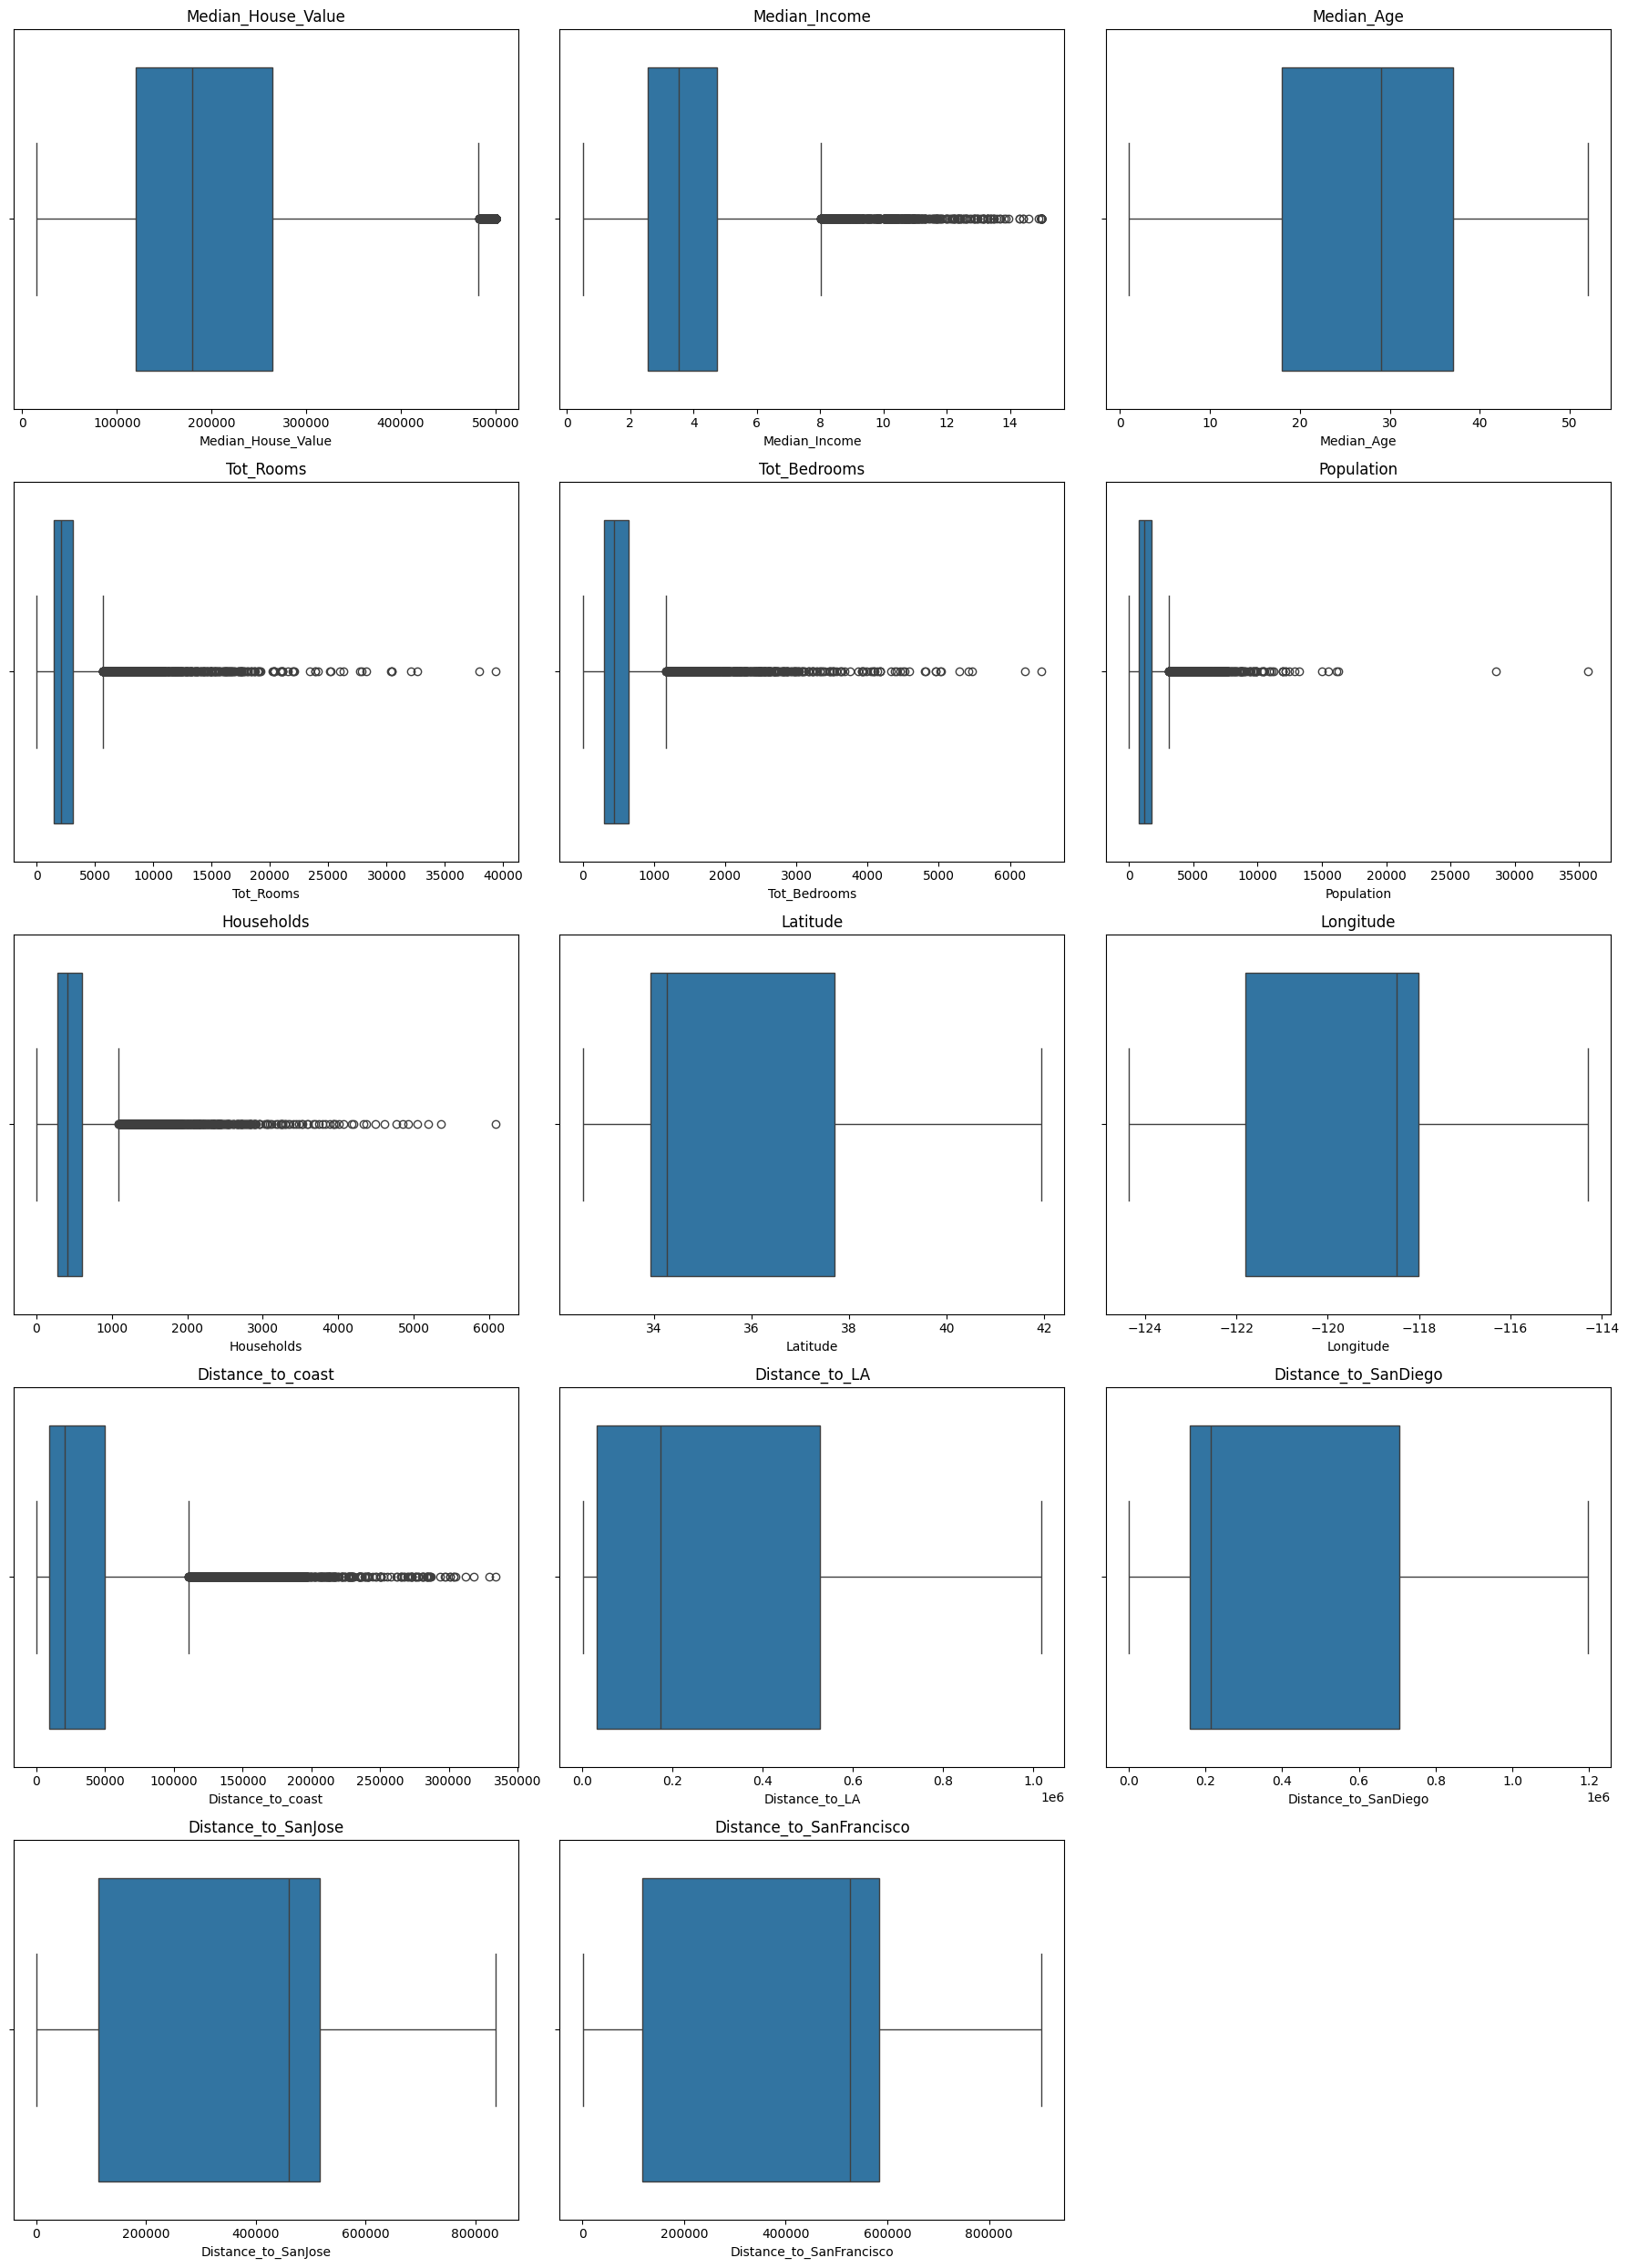

In [10]:
num_cols = numerical_cols
n_cols = 3                      # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


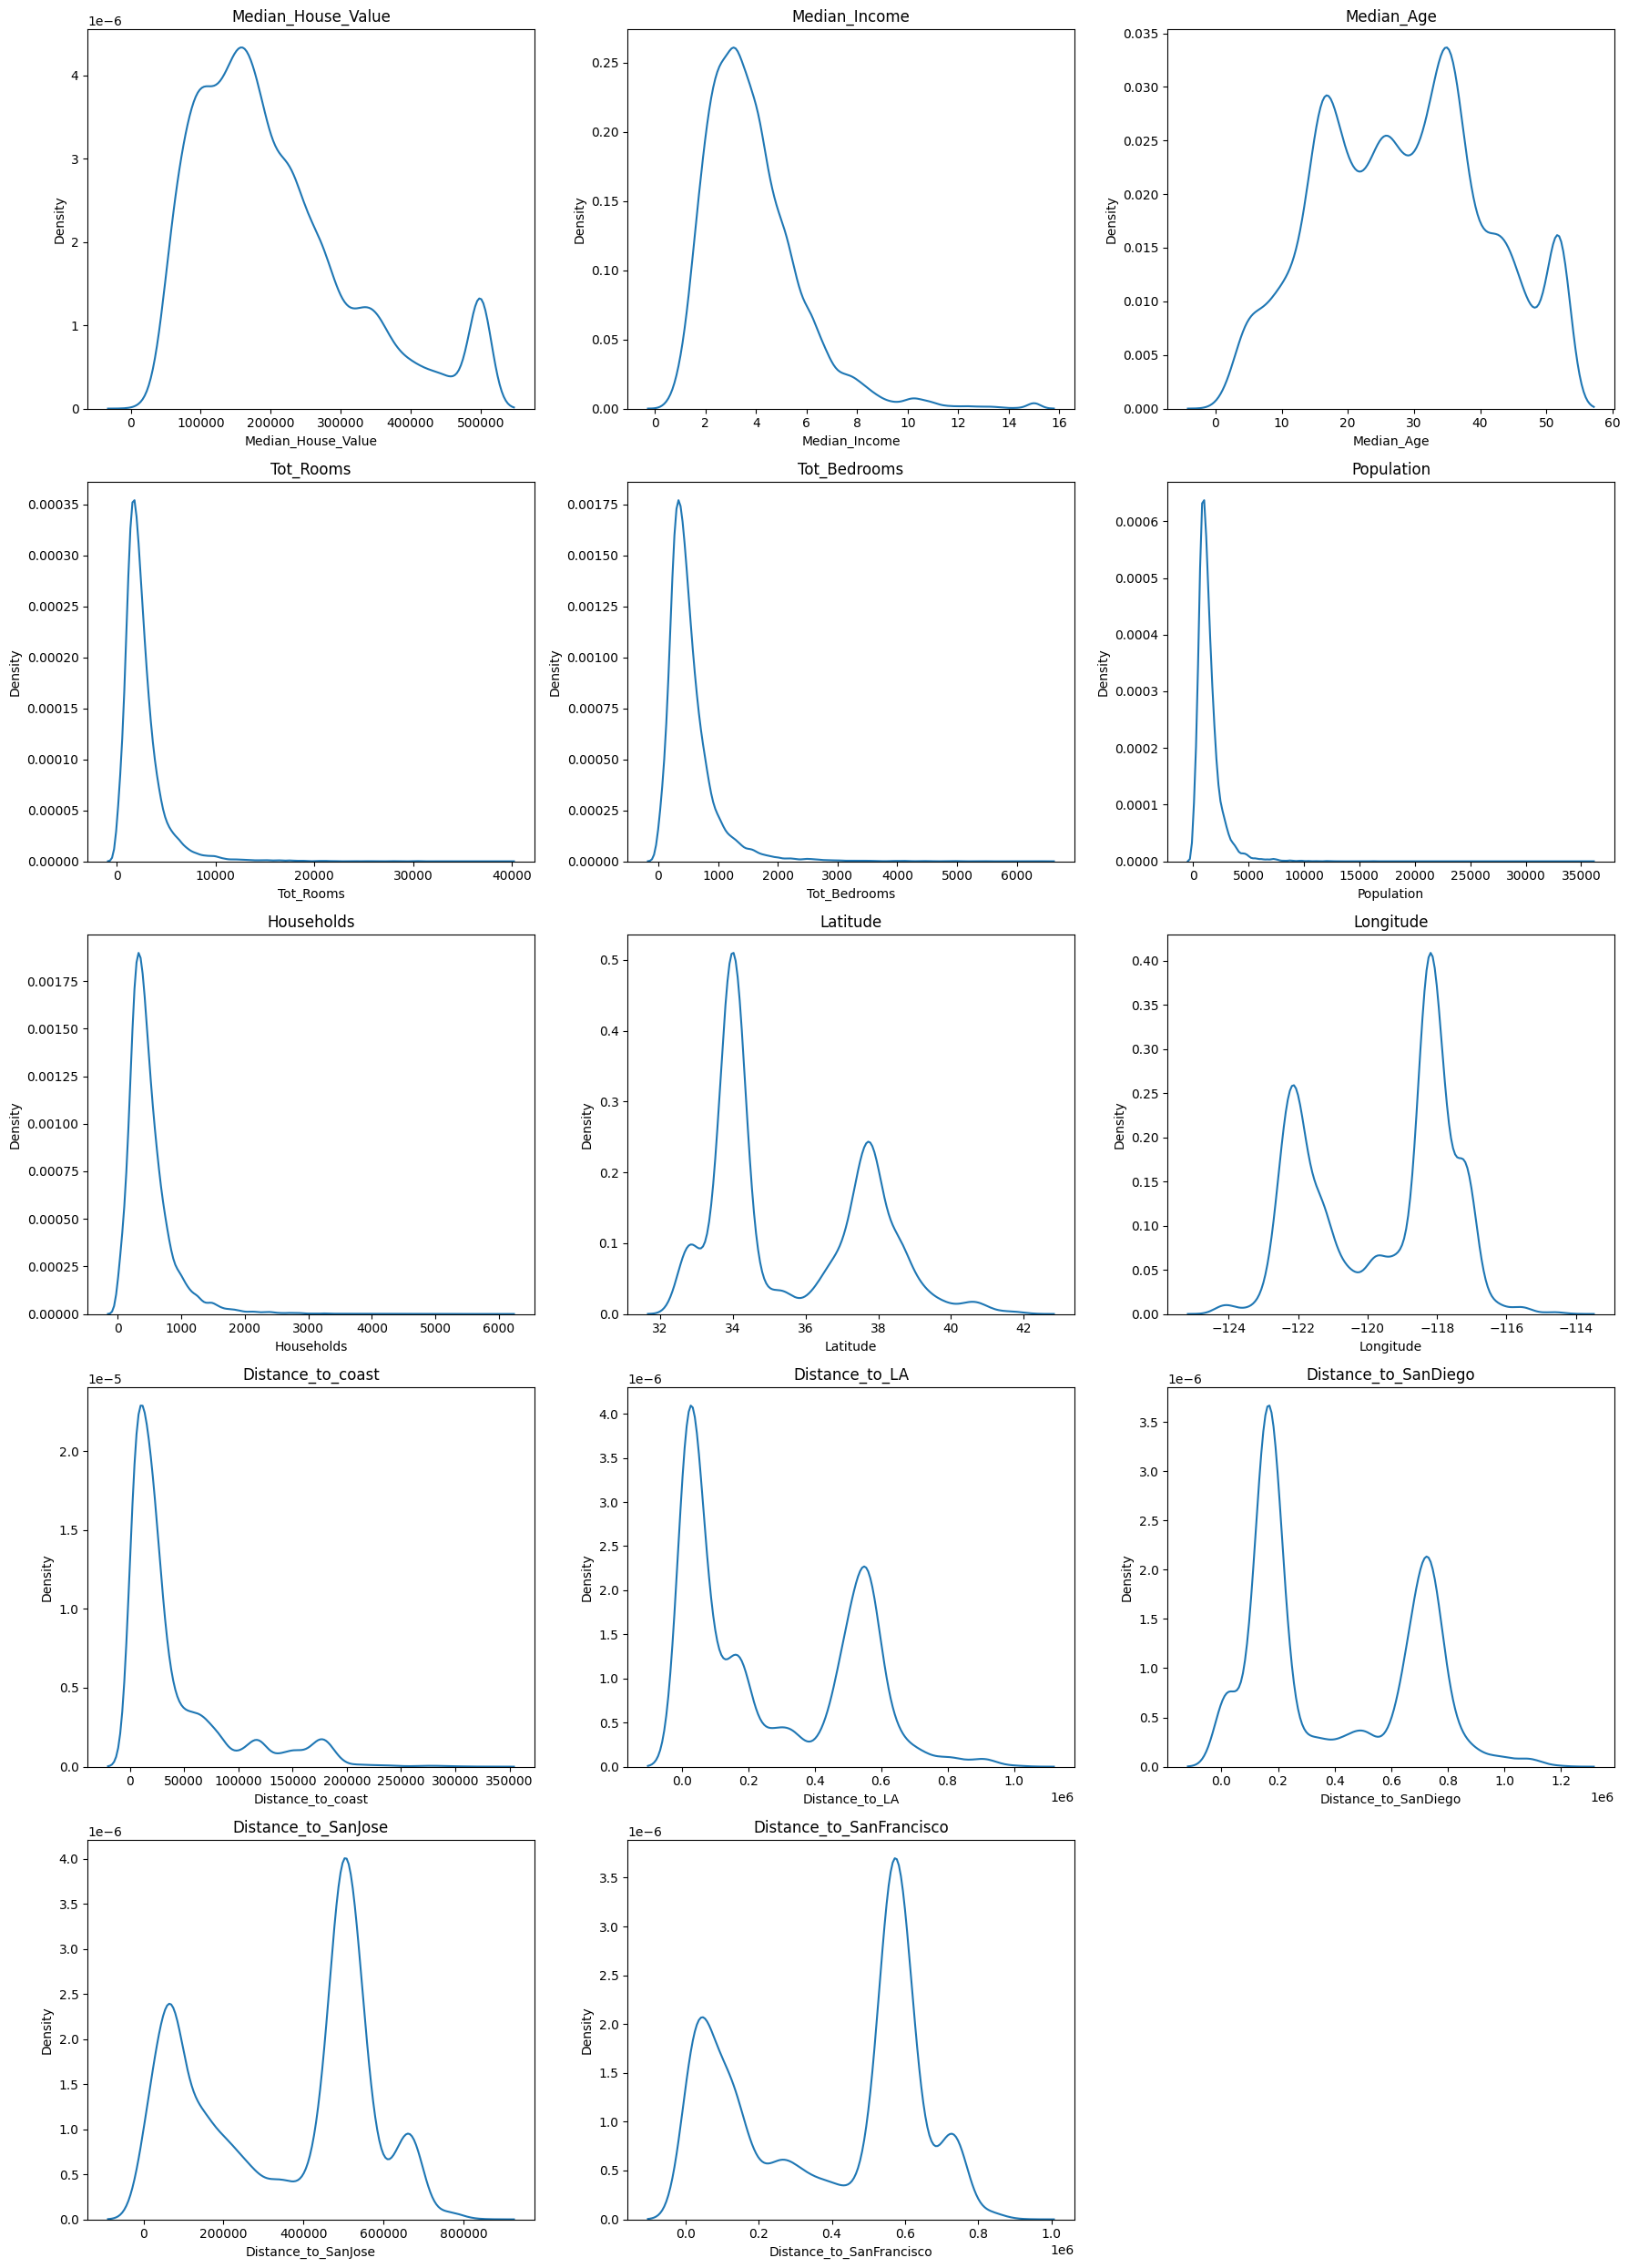

In [11]:
num_cols = numerical_cols
n_cols = 3                      # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(x=df[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [12]:
def remove_outliers(df):
    df_clean = df.copy()
    
    numerical_cols = df_clean.select_dtypes(include=np.number).columns
    
    for col in numerical_cols:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        df_clean = df_clean[
            (df_clean[col] >= lower_bound) & 
            (df_clean[col] <= upper_bound)
        ]
        
    return df_clean


In [13]:
df_clean = remove_outliers(df)

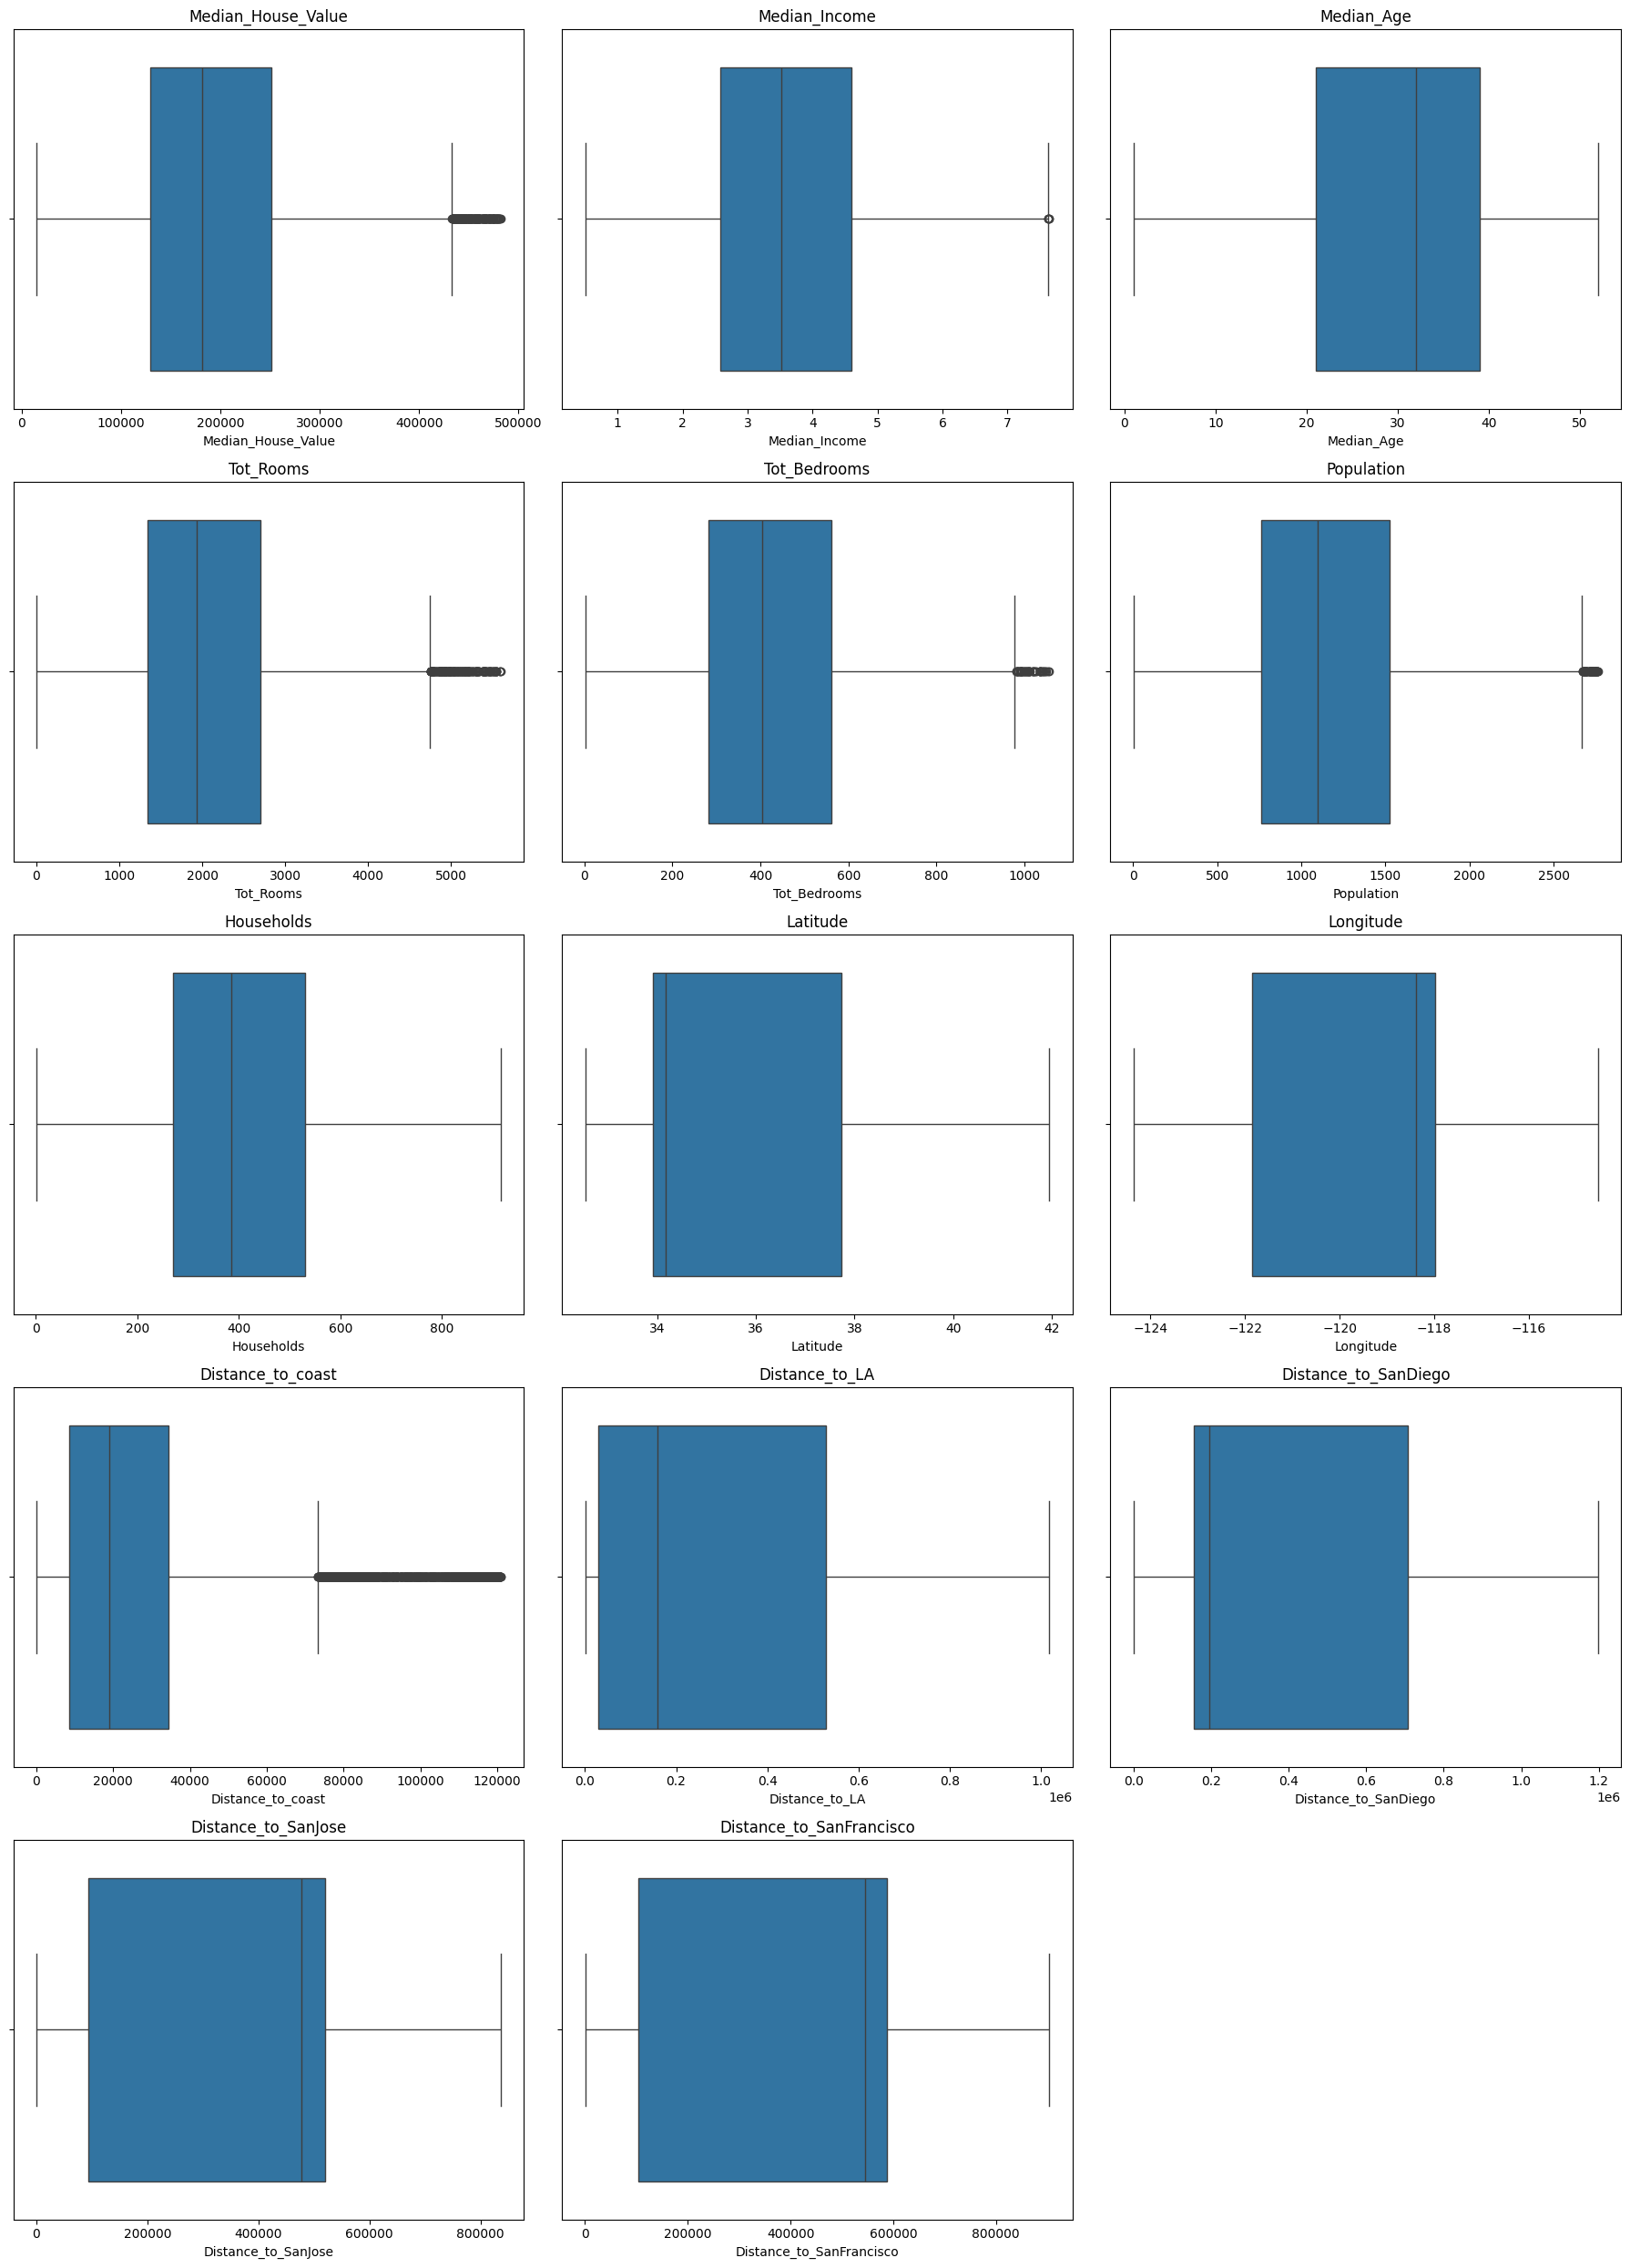

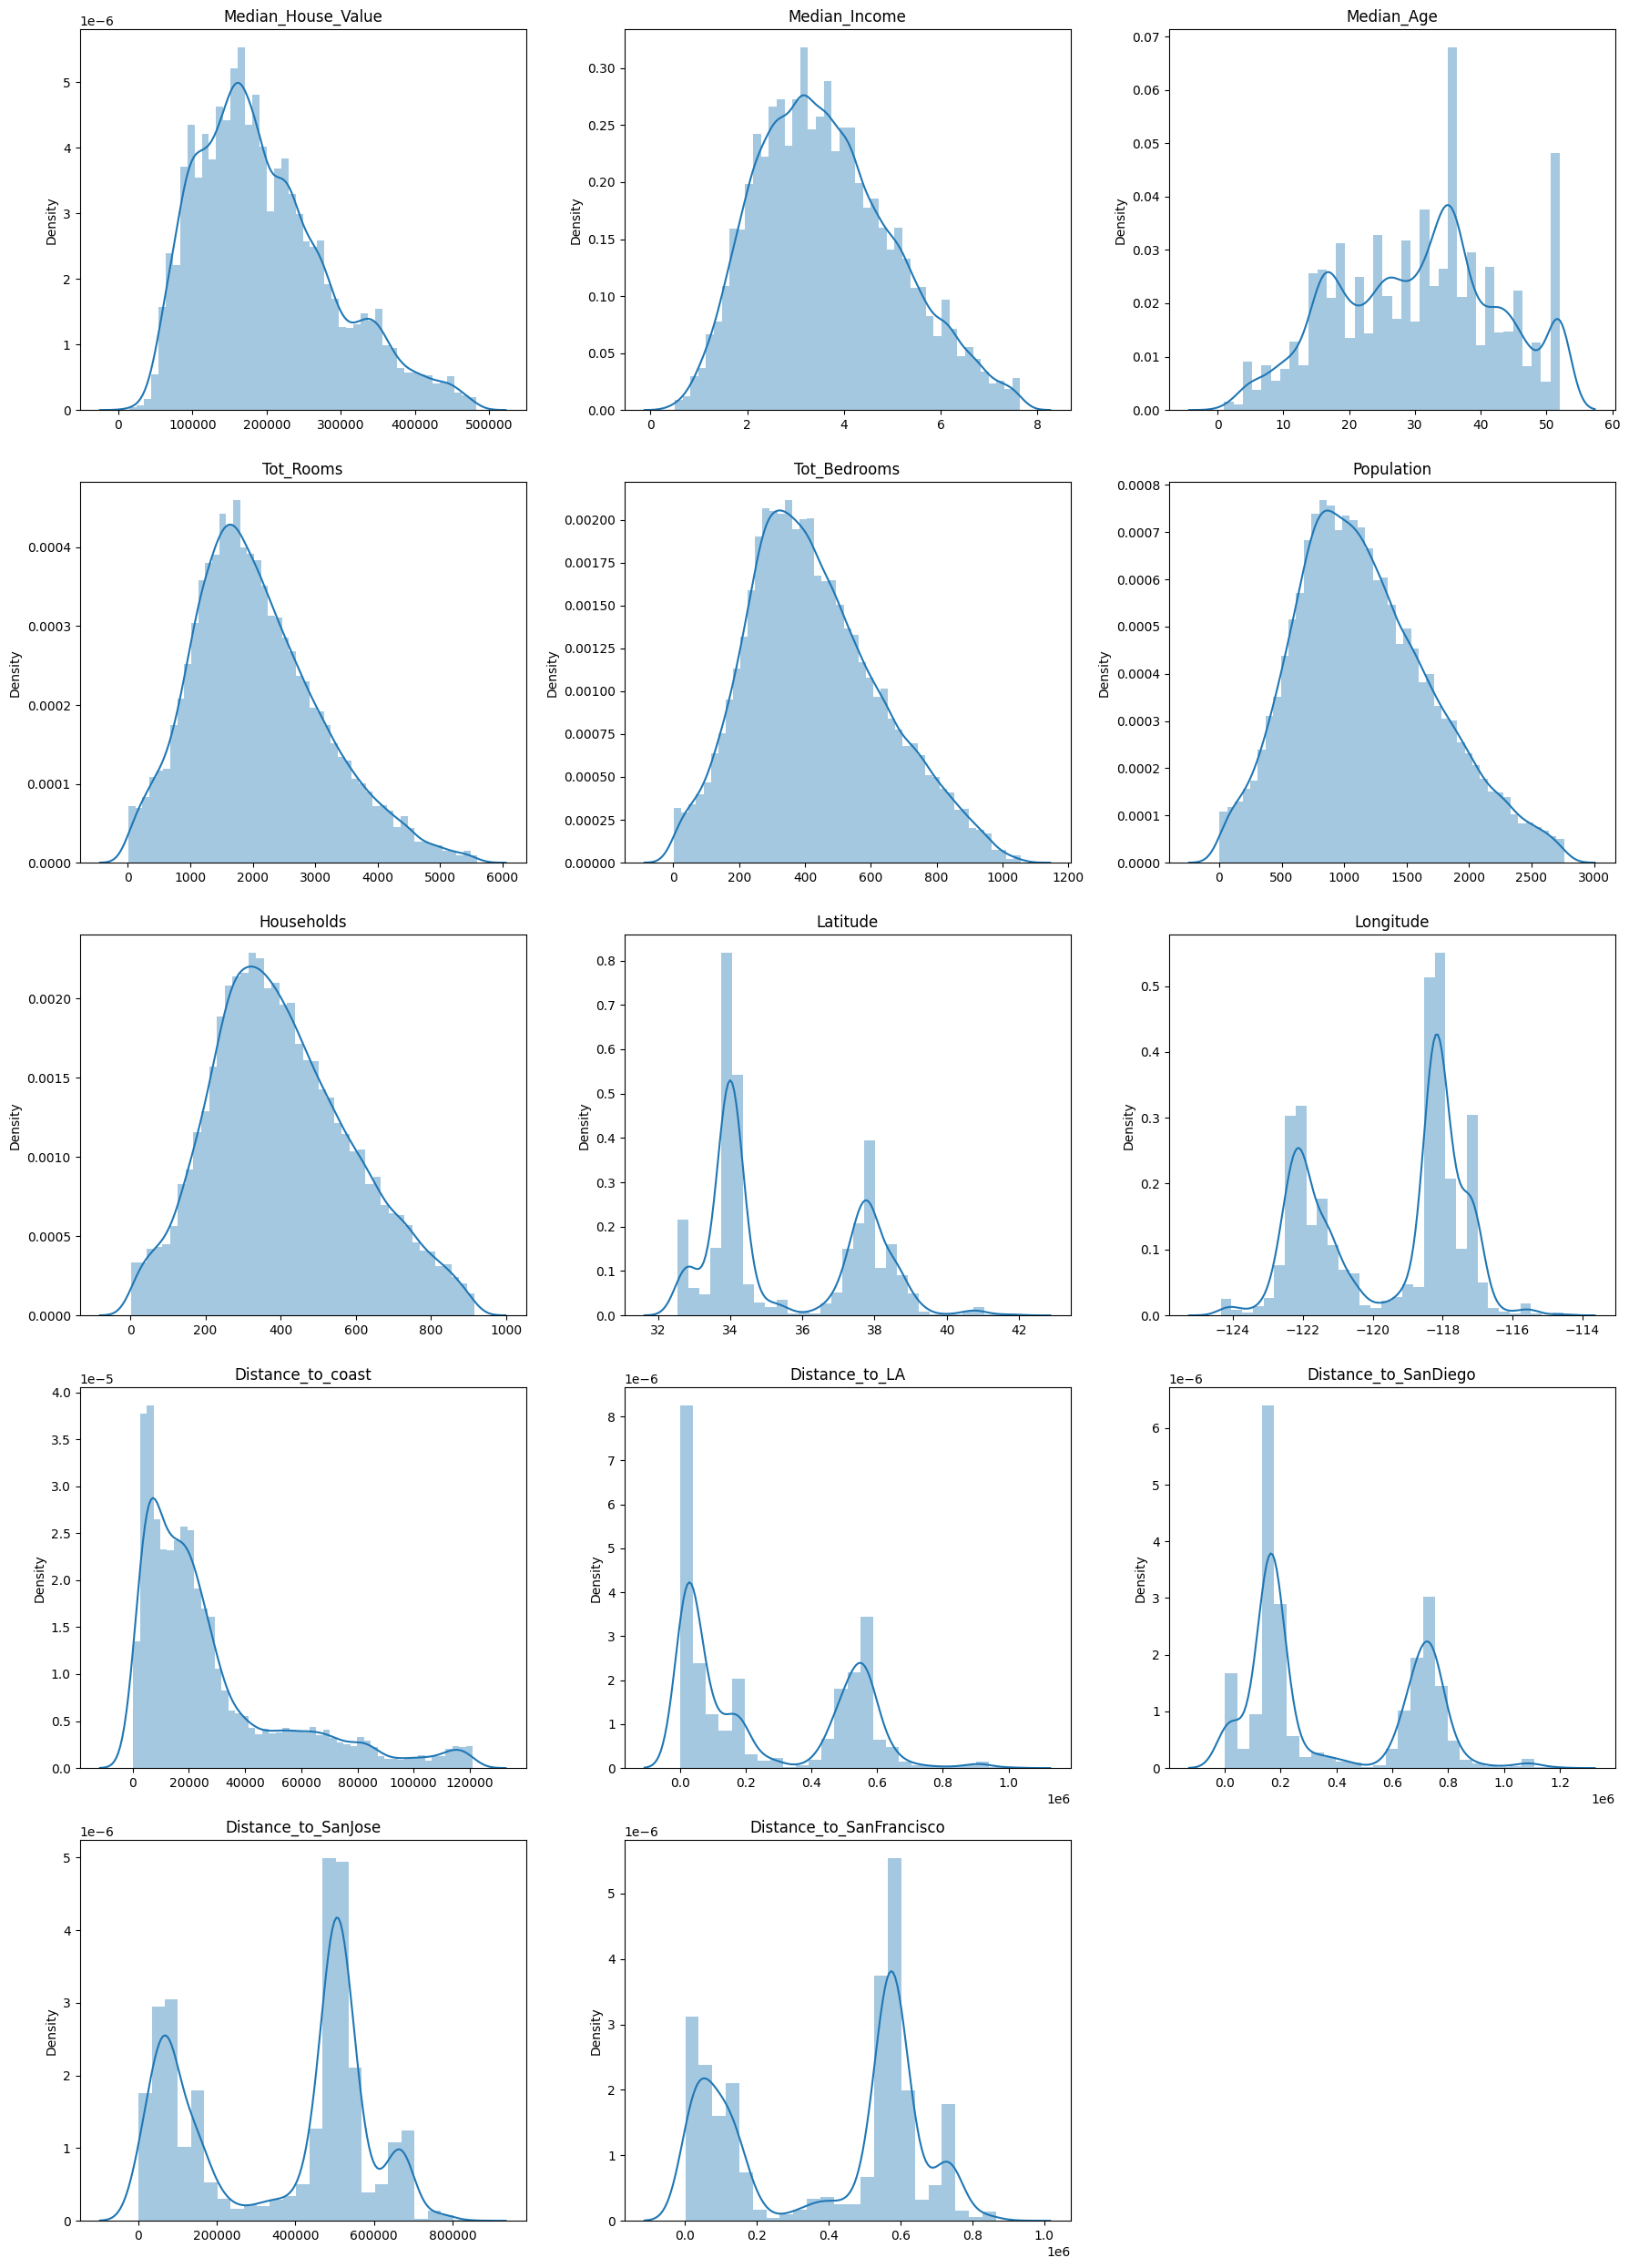

In [14]:
num_cols = numerical_cols
n_cols = 3                      # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


num_cols = numerical_cols
n_cols = 3                      # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.distplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


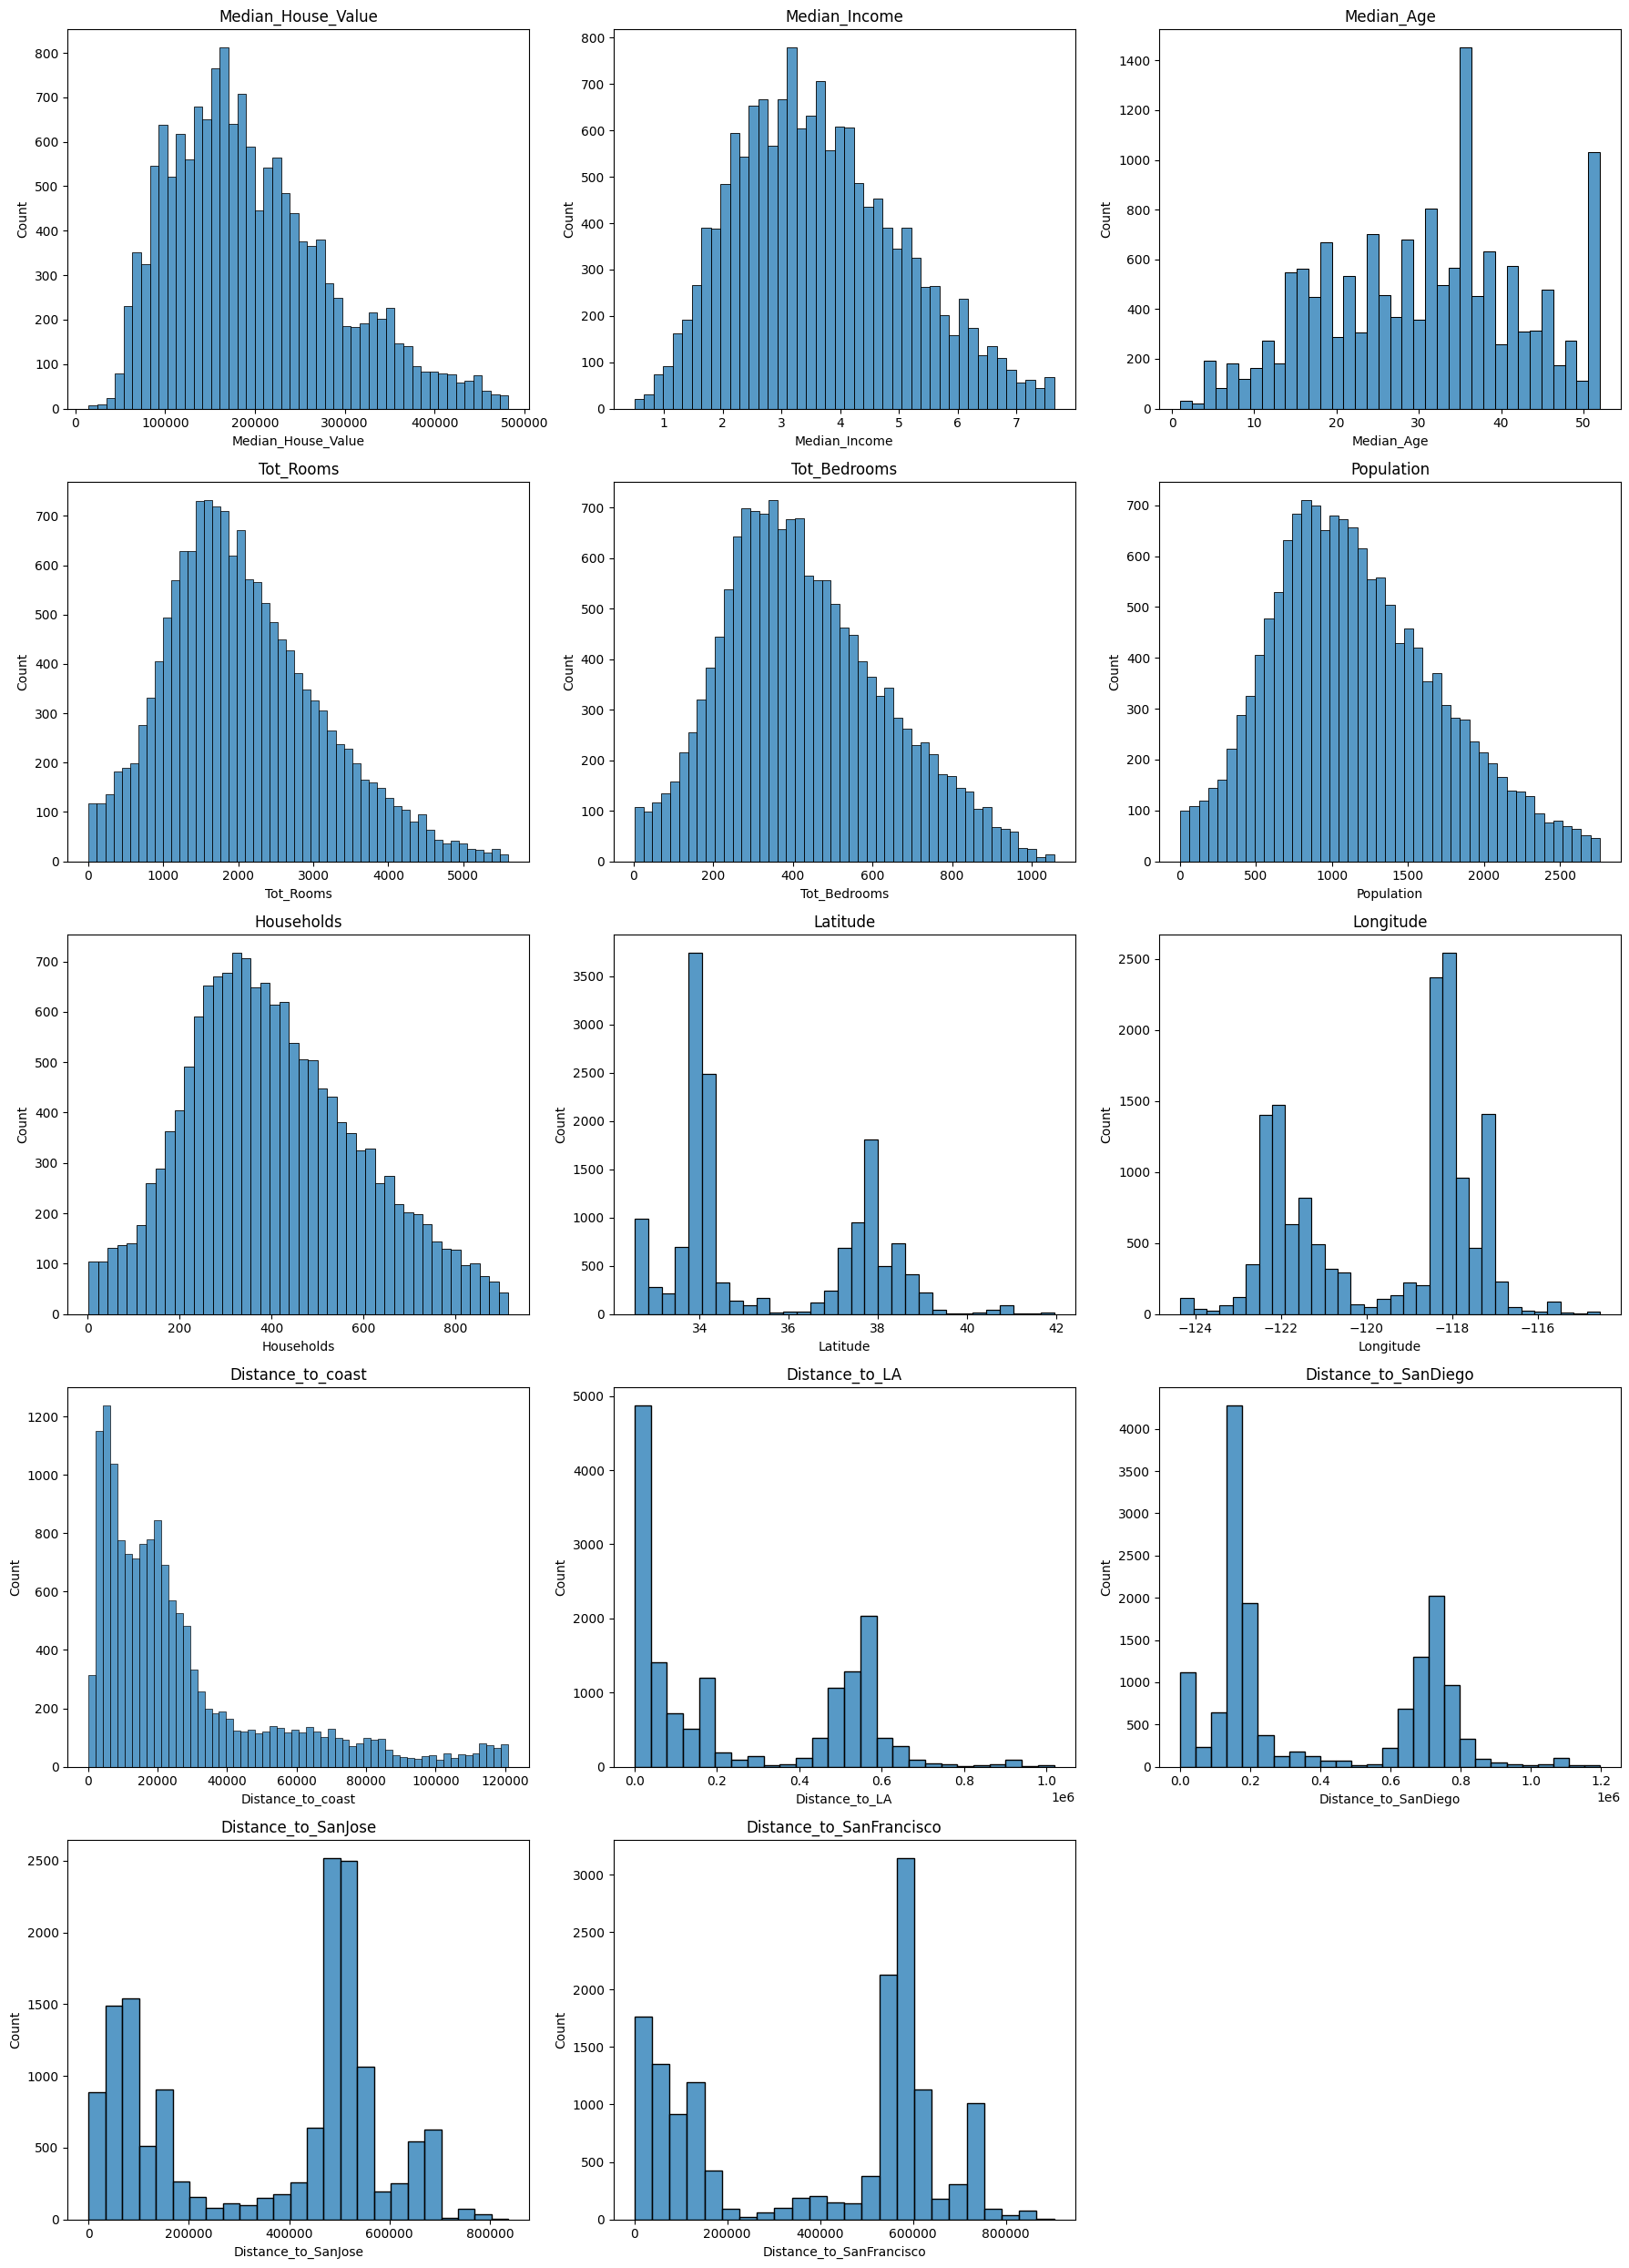

In [15]:
num_cols = numerical_cols
n_cols = 3                      # number of plots per row
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


In [16]:
df_clean['City'].value_counts()

City
Los Angeles        4639
San Diego          1321
Orange             1237
Alameda             890
Santa Clara         742
Sacramento          596
San Bernardino      586
Contra Costa        481
San Francisco       427
Riverside           417
San Joaquin         394
Sonoma              290
San Mateo           290
Ventura             286
Stanislaus          283
Santa Barbara       280
Santa Cruz          173
Solano              161
Kern                149
Monterey            149
Humboldt            134
San Luis Obispo     112
Imperial            107
Napa                103
Marin                98
Placer               95
Lake                 83
Mendocino            79
Merced               74
Yolo                 60
Tuolumne             55
Sutter               50
El Dorado            42
Amador               41
Yuba                 31
San Benito           29
Fresno               19
Shasta               17
Del Norte            15
Colusa               12
Calaveras            12
Siskiyou   

In [17]:
df_clean['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     7259
INLAND        3875
NEAR OCEAN    2134
NEAR BAY      1813
ISLAND           5
Name: count, dtype: int64

<Axes: xlabel='ocean_proximity', ylabel='Count'>

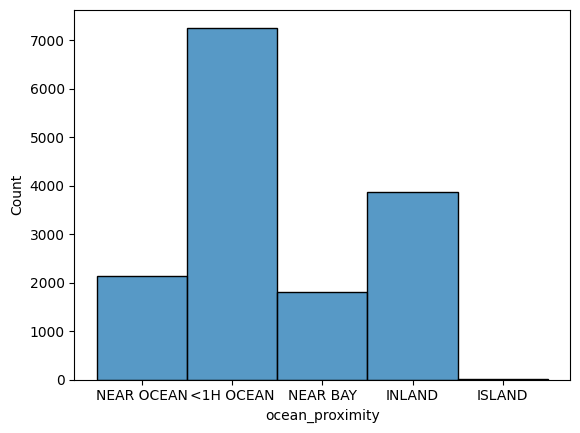

In [18]:
sns.histplot(df_clean['ocean_proximity'])

In [19]:
print("Skewness:")
print(df_clean[numerical_cols].skew())
print("\nKurtosis:")
print(df_clean[numerical_cols].kurtosis())


Skewness:
Median_House_Value          0.727204
Median_Income               0.425645
Median_Age                 -0.070016
Tot_Rooms                   0.594552
Tot_Bedrooms                0.434500
Population                  0.448755
Households                  0.371643
Latitude                    0.490314
Longitude                  -0.321717
Distance_to_coast           1.602228
Distance_to_LA              0.482954
Distance_to_SanDiego        0.431613
Distance_to_SanJose        -0.277004
Distance_to_SanFrancisco   -0.311212
dtype: float64

Kurtosis:
Median_House_Value          0.048676
Median_Income              -0.338409
Median_Age                 -0.759809
Tot_Rooms                   0.142248
Tot_Bedrooms               -0.264065
Population                 -0.216069
Households                 -0.327076
Latitude                   -1.230901
Longitude                  -1.390773
Distance_to_coast           2.021739
Distance_to_LA             -1.280994
Distance_to_SanDiego       -1.407126
Di

In [20]:
# threshold for skewness
SKEW_THRESHOLD = 1.0

# numerical columns
numerical_cols = df_clean.select_dtypes(include=np.number).columns

# apply log1p only to highly skewed features
for col in numerical_cols:
    skewness = df_clean[col].skew()
    
    if abs(skewness) > SKEW_THRESHOLD:
        df_clean[col] = np.log1p(df_clean[col])

# check skewness after transformation
df_clean[numerical_cols].skew()


Median_House_Value          0.727204
Median_Income               0.425645
Median_Age                 -0.070016
Tot_Rooms                   0.594552
Tot_Bedrooms                0.434500
Population                  0.448755
Households                  0.371643
Latitude                    0.490314
Longitude                  -0.321717
Distance_to_coast          -0.284236
Distance_to_LA              0.482954
Distance_to_SanDiego        0.431613
Distance_to_SanJose        -0.277004
Distance_to_SanFrancisco   -0.311212
dtype: float64

Housing prices show strong spatial dependence, with significantly higher values concentrated near the California coast and major metropolitan areas such as the Bay Area and Los Angeles.

A clear inland price decline is observed, indicating that distance from the coast and urban centers plays a major role in determining house values.

Geographical features (latitude, longitude, and distance-based variables) are strong predictors, justifying their inclusion in the regression model.

In [21]:
df_clean['rooms_per_household'] = df_clean['Tot_Rooms'] / df_clean['Households']
df_clean['bedrooms_per_room'] = df_clean['Tot_Bedrooms'] / df_clean['Tot_Rooms']
df_clean['population_per_household'] = df_clean['Population'] / df_clean['Households']
df_clean.head()

,Median_House_Value,Median_Income,Median_Age,Tot_Rooms,Tot_Bedrooms,Population,Households,Latitude,Longitude,Distance_to_coast,Distance_to_LA,Distance_to_SanDiego,Distance_to_SanJose,Distance_to_SanFrancisco,ocean_proximity,City,rooms_per_household,bedrooms_per_room,population_per_household
1071,482200.0,6.8553,33,5057,790,2021,748,33.81,-118.37,8.661365,29348.32755,165644.8194,505086.4105,572981.6462,NEAR OCEAN,Los Angeles,6.760695,0.156219,2.701872
1072,481500.0,6.6321,36,2334,430,1033,407,33.89,-118.40,8.184586,23091.58644,174082.0997,496387.7610,564309.2222,<1H OCEAN,Los Angeles,5.734644,0.184233,2.538084
1075,480800.0,6.3230,19,2930,428,1481,430,33.51,-117.68,9.263678,79682.69424,100676.5219,571419.2548,639446.6935,<1H OCEAN,Orange,6.813953,0.146075,3.444186
1077,480600.0,5.3441,36,1245,211,508,221,33.79,-118.13,8.570782,30988.53845,149618.9119,520747.5681,588740.6988,NEAR OCEAN,Los Angeles,5.633484,0.169478,2.298643
1078,480100.0,6.1014,44,2017,343,958,382,34.01,-118.47,8.142418,21377.56270,188379.2583,481937.2412,549882.5947,<1H OCEAN,Los Angeles,5.280105,0.170055,2.507853


In [22]:
X_num = df[numerical_cols]

vif = pd.DataFrame()
vif["feature"] = X_num.columns
vif["VIF"] = [variance_inflation_factor(X_num.values, i)
              for i in range(X_num.shape[1])]
vif

,feature,VIF
0,Median_House_Value,11.889682
1,Median_Income,15.289289
2,Median_Age,8.849342
3,Tot_Rooms,31.900760
4,Tot_Bedrooms,95.812133
5,Population,17.914298
6,Households,95.374298
7,Latitude,31233.898498
8,Longitude,26323.428217
9,Distance_to_coast,6.392997


### Bivariate Analysis

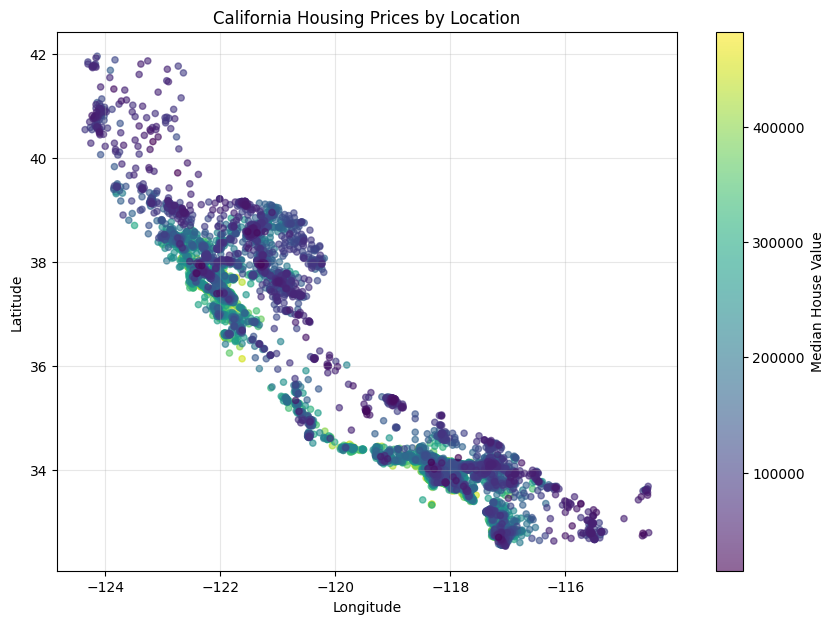

In [23]:
plt.figure(figsize=(10, 7))

sc = plt.scatter(
    df_clean['Longitude'],
    df_clean['Latitude'],
    c=df_clean['Median_House_Value'],
    cmap='viridis',          # better perceptual colormap than jet
    alpha=0.6,
    s=20                     # point size
)

plt.colorbar(sc, label='Median House Value')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices by Location')

plt.grid(alpha=0.3)
plt.show()


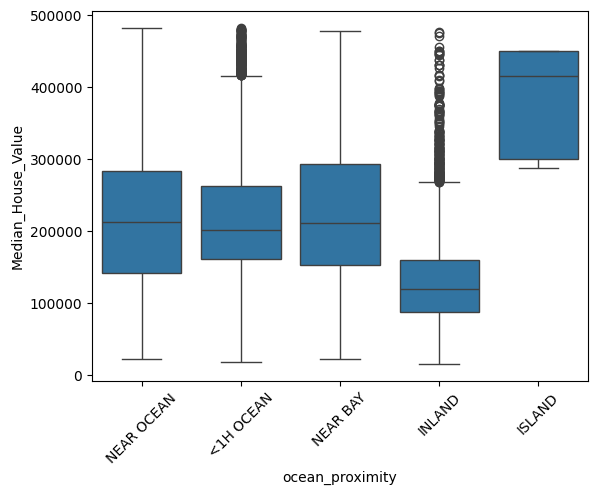

In [29]:
sns.boxplot(
    x=df_clean['ocean_proximity'],
    y=df_clean['Median_House_Value']
)
plt.xticks(rotation=45)
plt.show()


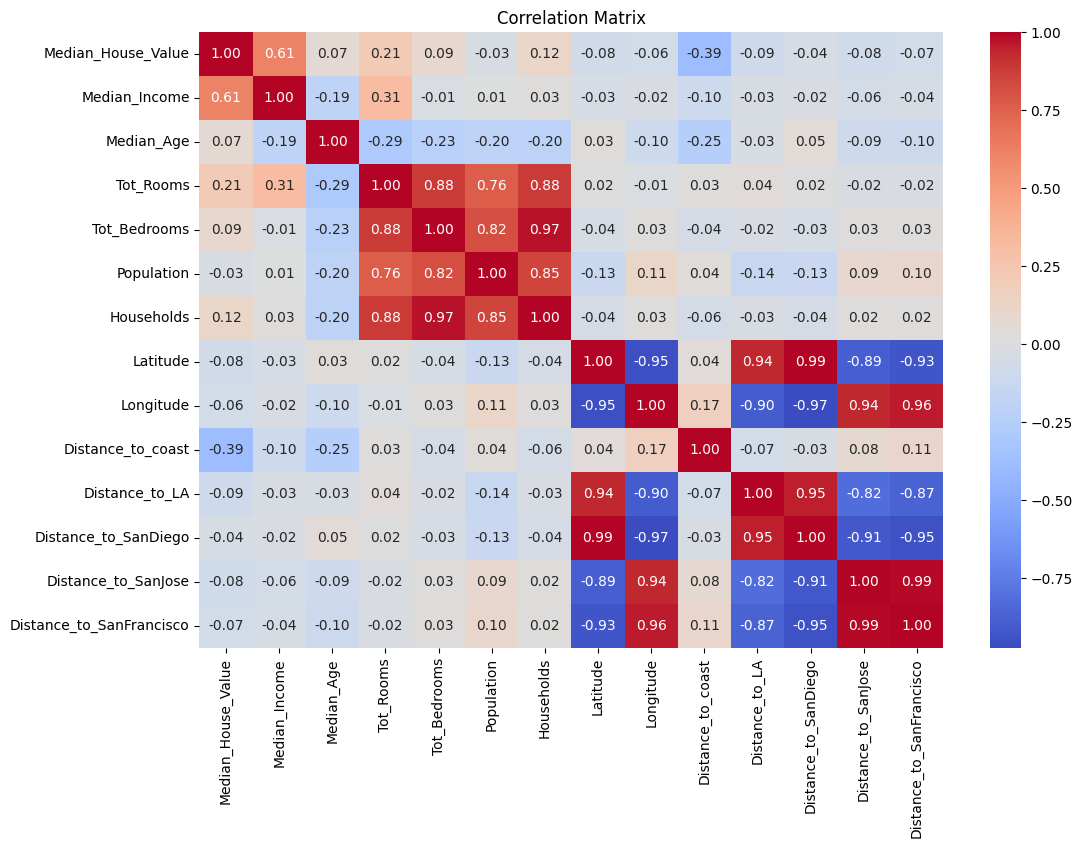

In [32]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df_clean[numerical_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.show()


In [ ]:
df_clean.shape

### Multivariate Anlaysis